In [6]:

import numpy as np
import torch
import torch.nn as nn
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import wandb

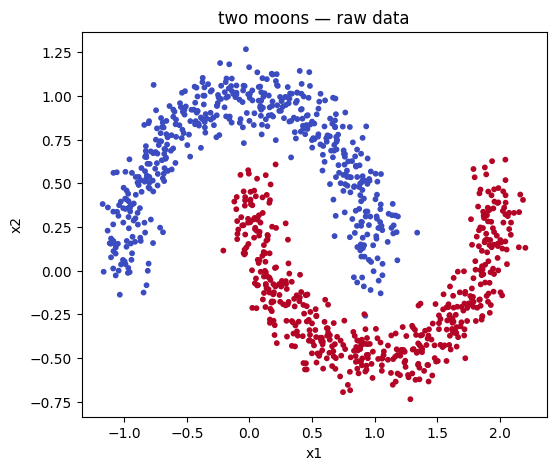

In [2]:
X, y = make_moons(n_samples=1000, noise=0.1, random_state=0) # make a data distribution! each (x1,x2) maps to some probability y

# visualize!
plt.figure(figsize=(6,5))
plt.scatter(X[:,0], X[:,1], c=y, s=10, cmap='coolwarm')
plt.title("two moons — raw data")
plt.xlabel("x1"); plt.ylabel("x2")
plt.savefig("raw_data.png", dpi=120, bbox_inches="tight")
plt.show()

In [5]:
# cool now we want the mlp to be able to distinguish between these classes!

# first we must make said MLP

class MLP(nn.Module):
    def __init__(self, hidden=67):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(2, hidden), # first layer preactivations: 2 neurons
            nn.ReLU(),
            nn.Linear(hidden, hidden), # two 32-layer neurons because funsies
            nn.ReLU(),
            nn.Linear(hidden, 2)
        )
    
    def forward(self, x):
        return self.net(x)


# wow fire!
model = MLP()

In [ ]:
# wandb authorization
wandb.login(key="haha_not_this_time")
# REMINDER TO DELETE THIS BEFORE COMMITTING!!!

wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: [wandb.login()] Using explicit session credentials for https://api.wandb.ai.
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: C:\Users\purva\_netrc
wandb: W&B API key is configured. Use `wandb login --relogin` to force relogin


True

In [7]:
# how are we defining loss for this thing??

# for binary classification we want to argmax the probability of label y matching input [x1, x2]T
# we can model this probability as Bernoulli because it simply is or isn't, so just one parameter p is needed
# this ALSO means our output logit better be in [0,1] so it can represent a probability of being a particular label
# so we sigmoid it!
# so what we want is to estimate the parameter p for any given input x ~ sigmoid(model(x)) --> i'll refer to sigmoid(model(x)) as simply f
# we can represent this probability with a neat little expression: (1-f)**(1-y) * (f)**y --> this ONLY works because we're guaranteed y is either one class or the other ("binary" :O)

# THIS IS EXPR FOR ONE TRAINING EXAMPLE!!
# to argmax the "aggregated" probability of a correct label y given input x, we want to multiply the probabilities from each training example together!
# and now we just argmax this expression over the parameters of the model!
# ...which is equivalent to argminning the negative log of this expression
# and wow there we go!

lossfunc = nn.CrossEntropyLoss()

# i will come back to update this once i have made this adam guys acquaintance and understood some of the math
# but for now i am just defaulting to "this line is in a lot of pytorch code that exists and does the desired argminning"

optimizer = torch.optim.Adam(model.parameters(), lr=1e-2)

# some logging stuff im told (thanks internet)

wandb.init(project="mlp-test", config={"hidden": 32, "lr": 1e-2, "epochs": 200})

# cool now lets train test split!

X_tr, X_val, y_tr, y_val = train_test_split(X, y, test_size=0.2, random_state=0)

X_tr  = torch.tensor(X_tr,  dtype=torch.float32)
y_tr  = torch.tensor(y_tr,  dtype=torch.long)
X_val = torch.tensor(X_val, dtype=torch.float32)
y_val = torch.tensor(y_val, dtype=torch.long)

wandb: Currently logged in as: pmarf (pmarf-org) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


In [8]:
# the actual training!! insert kung fu panda quote idk

for i in range(200):
    model.train() # tells us we are Training?? useless rn it seems
    optimizer.zero_grad() # ok yes do this before u call backwards to clear the old gradients
    all_the_preds = model(X_tr) #  feed the entirety of the training set to the model
    L = lossfunc(all_the_preds, y_tr) # aggregated badness of model
    L.backward() # backprop!
    optimizer.step() # weight update based on grads

    model.eval() # ok so now we are NOT training because we just want to see how bad the model is doing on the test set as of this moment?
    with torch.no_grad(): # no wasted space keeping track of gradients!
        val_preds = model(X_val)
        L_val = lossfunc(val_preds, y_val)
        val_accuracy = (val_preds.argmax(1) == y_val).float().mean() 
        # the argmax bit is because we dont actually gaf about the continuous probability so we can afford to just take the highest pre-sigmoid output!
        # taking the mean across all validation examples (X_v, y_v) tells us the accuracy (correct/total), again because y can only take on 0 or 1

    wandb.log({
        "train_loss": L.item(),
        "val_loss": L_val.item(),
        "val_acc": val_accuracy.item()
    })
    if i % 20 == 0:
        print(f"epoch {i:3d} | train {L.item():.3f} | val {L_val.item():.3f} | acc {val_accuracy.item():.3f}")

epoch   0 | train 0.715 | val 0.614 | acc 0.750
epoch  20 | train 0.080 | val 0.074 | acc 0.975
epoch  40 | train 0.008 | val 0.006 | acc 1.000
epoch  60 | train 0.004 | val 0.003 | acc 1.000
epoch  80 | train 0.003 | val 0.002 | acc 1.000
epoch 100 | train 0.003 | val 0.002 | acc 1.000
epoch 120 | train 0.003 | val 0.002 | acc 1.000
epoch 140 | train 0.003 | val 0.001 | acc 1.000
epoch 160 | train 0.002 | val 0.001 | acc 1.000
epoch 180 | train 0.002 | val 0.001 | acc 1.000


wandb: ERROR The nbformat package was not found. It is required to save notebook history.


saved decision_boundary.png


train_loss,█▄▃▃▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
val_acc,▁▃▅▆████████████████████████████████████
val_loss,█▇▆▄▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
train_loss,0.00228
val_acc,1
val_loss,0.00108


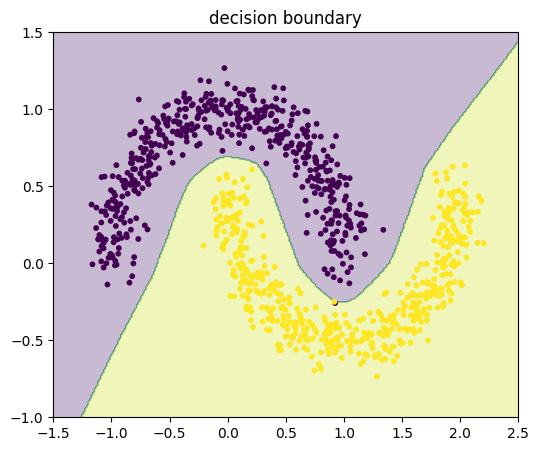

In [9]:
# yay now we visualize!!

xx, yy = np.meshgrid(np.linspace(-1.5, 2.5, 300), np.linspace(-1.0, 1.5, 300)) # define x and y axes
grid = torch.tensor(np.c_[xx.ravel(), yy.ravel()], dtype=torch.float32) # make a grid!!
with torch.no_grad():
    preds = model(grid).argmax(1).numpy().reshape(xx.shape) # run the model on the entire grid of data (all possible (x,y) in the grid are the set of Xes))
 
plt.figure(figsize=(6, 5))
plt.contourf(xx, yy, preds, alpha=0.3) # this is the decision boundary!!
plt.scatter(X[:, 0], X[:, 1], c=y, s=10)
plt.title("decision boundary")
plt.savefig("decision_boundary.png", dpi=120, bbox_inches="tight")
wandb.log({"decision_boundary": wandb.Image("decision_boundary.png")})
print("saved decision_boundary.png")
wandb.finish()